In [2]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import configparser
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from PIL import Image
from tqdm.auto import tqdm

ROOTS = [Path('/kaggle/input'), Path('/kaggle/working/mot17')]
OUTPUT = Path('/kaggle/working/parte1_mot17')
OUTPUT.mkdir(parents=True, exist_ok=True)

PUBLIC_DETECTOR = 'FRCNN'
PUBLIC_SCORE_THRESHOLD = None  # não supor que scores públicos são probabilidades
TV_SCORE_THRESHOLD = 0.5
ASSOCIATION_IOU = 0.3
EVALUATION_IOU = 0.5
MAX_MISSED = 5
SMOKE_TEST = True
MAX_FRAMES = 30 if SMOKE_TEST else None

sequences = sorted({
    p.parent.parent
    for root in ROOTS if root.exists()
    for p in root.rglob('det.txt')
    if p.parent.name == 'det'
    and p.parent.parent.name.endswith('-' + PUBLIC_DETECTOR)
    and (p.parent.parent / 'img1').is_dir()
    and (p.parent.parent / 'gt' / 'gt.txt').is_file()
})

by_name = {}
for seq in sequences:
    by_name.setdefault(seq.name, seq)
sequences = list(by_name.values())



In [3]:
for seq in sequences:
    print(seq)

/kaggle/input/datasets/ahmedsamir1598/mot17challenge/MOT17/train/MOT17-02-FRCNN
/kaggle/input/datasets/ahmedsamir1598/mot17challenge/MOT17/train/MOT17-04-FRCNN
/kaggle/input/datasets/ahmedsamir1598/mot17challenge/MOT17/train/MOT17-05-FRCNN
/kaggle/input/datasets/ahmedsamir1598/mot17challenge/MOT17/train/MOT17-09-FRCNN
/kaggle/input/datasets/ahmedsamir1598/mot17challenge/MOT17/train/MOT17-10-FRCNN
/kaggle/input/datasets/ahmedsamir1598/mot17challenge/MOT17/train/MOT17-11-FRCNN
/kaggle/input/datasets/ahmedsamir1598/mot17challenge/MOT17/train/MOT17-13-FRCNN


In [4]:
def frame_paths(seq):
    paths = sorted((p for p in (seq / 'img1').iterdir()
                    if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}),
                   key=lambda p: int(p.stem))
    if not paths:
        raise ValueError(f'Sem imagens: {seq}')
    return paths[:MAX_FRAMES] if MAX_FRAMES is not None else paths

def xywh_to_xyxy(values):
    boxes = np.asarray(values, dtype=float).reshape(-1, 4).copy()
    boxes[:, :2] -= 1
    boxes[:, 2:] += boxes[:, :2]
    return boxes

def read_mot(path):
    if path.stat().st_size == 0:
        return np.empty((0, 10))
    return pd.read_csv(path, header=None).to_numpy(dtype=float)

def load_public(seq, frames):
    table = read_mot(seq / 'det' / 'det.txt')
    result = {f: np.empty((0, 5)) for f in frames}
    for f in frames:
        rows = table[table[:, 0] == f]
        keep = np.isfinite(rows[:, 2:7]).all(axis=1)
        keep &= (rows[:, 4] > 0) & (rows[:, 5] > 0)
        if PUBLIC_SCORE_THRESHOLD is not None:
            keep &= rows[:, 6] >= PUBLIC_SCORE_THRESHOLD
        rows = rows[keep]
        result[f] = np.column_stack((xywh_to_xyxy(rows[:, 2:6]), rows[:, 6]))
    return result

def load_gt(seq, frames):
    table = read_mot(seq / 'gt' / 'gt.txt')
    if table.shape[1] < 8:
        raise ValueError('GT MOT17 deve conter marcação e classe.')
    gt, ignored = {}, {}
    for f in frames:
        rows = table[table[:, 0] == f]
        valid = (rows[:, 6] != 0) & (rows[:, 7] == 1)
        ignore = (rows[:, 6] == 0) | np.isin(rows[:, 7], [2, 7, 8, 12])
        gt[f] = np.column_stack((rows[valid, 1], xywh_to_xyxy(rows[valid, 2:6])))
        ignored[f] = xywh_to_xyxy(rows[ignore, 2:6])
        assert len(np.unique(gt[f][:, 0])) == len(gt[f]), 'GT duplicado no quadro'
    return gt, ignored

def iou_matrix(a, b):
    a = np.asarray(a, dtype=float).reshape(-1, 4)
    b = np.asarray(b, dtype=float).reshape(-1, 4)
    tl = np.maximum(a[:, None, :2], b[None, :, :2])
    br = np.minimum(a[:, None, 2:], b[None, :, 2:])
    wh = np.maximum(br - tl, 0)
    inter = wh[..., 0] * wh[..., 1]
    aa = np.maximum(a[:, 2:] - a[:, :2], 0).prod(axis=1)
    ab = np.maximum(b[:, 2:] - b[:, :2], 0).prod(axis=1)
    return inter / np.maximum(aa[:, None] + ab[None, :] - inter, 1e-12)

def gated_hungarian(similarities, threshold):
    # Primeiro maximizar quantidade de pares válidos; depois soma das IoUs.
    # Penalizar pares inválidos antes de resolver; não filtrar apenas depois.
    if 0 in similarities.shape:
        return []
    valid = similarities >= threshold
    bonus = min(similarities.shape) + 1
    reward = np.where(valid, bonus + similarities, 0.)
    rows, cols = linear_sum_assignment(-reward)
    return [(int(r), int(c)) for r, c in zip(rows, cols) if valid[r, c]]


In [5]:
import torch
import torchvision
import torchvision.ops.boxes as box_ops
from torchvision.models.detection import rpn, roi_heads
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
)

def own_nms(boxes, scores, iou_threshold):
    if boxes.numel() == 0:
        return torch.empty(0, dtype=torch.long, device=boxes.device)
    boxes = boxes.float()
    areas = (boxes[:, 2:] - boxes[:, :2]).clamp(min=0).prod(dim=1)
    order = torch.argsort(scores, descending=True, stable=True)
    kept = []
    while order.numel():
        current = order[0]
        kept.append(current)
        rest = order[1:]
        if not rest.numel():
            break
        tl = torch.maximum(boxes[current, :2], boxes[rest, :2])
        br = torch.minimum(boxes[current, 2:], boxes[rest, 2:])
        wh = (br - tl).clamp(min=0)
        inter = wh[:, 0] * wh[:, 1]
        iou = inter / (areas[current] + areas[rest] - inter).clamp(min=1e-12)
        order = rest[iou <= iou_threshold]
    return torch.stack(kept)

def own_batched_nms(boxes, scores, categories, iou_threshold):
    if boxes.numel() == 0:
        return torch.empty(0, dtype=torch.long, device=boxes.device)
    kept = []
    for category in torch.unique(categories):
        indices = torch.where(categories == category)[0]
        local = own_nms(boxes[indices], scores[indices], iou_threshold)
        kept.append(indices[local])
    kept = torch.cat(kept)
    return kept[torch.argsort(scores[kept], descending=True, stable=True)]

box_ops.nms = own_nms
box_ops.batched_nms = own_batched_nms
torchvision.ops.nms = own_nms
torchvision.ops.batched_nms = own_batched_nms
assert rpn.box_ops.batched_nms is own_batched_nms
assert roi_heads.box_ops.batched_nms is own_batched_nms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
transform = weights.transforms()
person_label = weights.meta['categories'].index('person')
model = fasterrcnn_resnet50_fpn(weights=weights).to(device).eval()
print('torch', torch.__version__, 'torchvision', torchvision.__version__, device)

@torch.inference_mode()
def detect_people(path):
    with Image.open(path) as image:
        tensor = transform(image.convert('RGB')).to(device)
        
    pred = model([tensor])[0]
    keep = (pred['labels'] == person_label) & (pred['scores'] >= TV_SCORE_THRESHOLD)
    return torch.cat((pred['boxes'][keep], pred['scores'][keep, None]), dim=1).cpu().numpy()


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 207MB/s] 


torch 2.10.0+cu128 torchvision 0.25.0+cu128 cuda


In [6]:
@torch.inference_mode()
def detect_people(path):
    with Image.open(path) as image:
        tensor = transform(image.convert('RGB')).to(device)
    pred = model([tensor])[0]
    keep = (pred['labels'] == person_label) & (pred['scores'] >= TV_SCORE_THRESHOLD)
    return torch.cat((pred['boxes'][keep], pred['scores'][keep, None]), dim=1).cpu().numpy()

Rastreador ingênuo

In [15]:
class IoUTracker:
    def __init__(self, threshold=ASSOCIATION_IOU, max_missed=MAX_MISSED):
        if max_missed < 1:
            raise ValueError('max_missed deve ser >= 1')
        self.threshold, self.max_missed = threshold, max_missed
        self.tracks = {}
        self.next_id = 1
        self.previous_frame = None

    def update(self, frame, detections):
        detections = np.asarray(detections).reshape(-1, 5)
        if self.previous_frame is not None and frame != self.previous_frame + 1:
            raise ValueError('Processe todos os quadros consecutivos, inclusive vazios.')
        candidates = [i for i, t in self.tracks.items() if t['last_frame'] == frame - 1]
        old_boxes = np.array([self.tracks[i]['box'] for i in candidates]).reshape(-1, 4)
        pairs = gated_hungarian(iou_matrix(old_boxes, detections[:, :4]), self.threshold)
        assigned = {d: candidates[t] for t, d in pairs}
        observed = set()
        output = []
        for d, detection in enumerate(detections):
            track_id = assigned.get(d)
            if track_id is None:
                track_id = self.next_id
                self.next_id += 1
            self.tracks[track_id] = {'box': detection[:4].copy(), 'last_frame': frame, 'missed': 0}
            observed.add(track_id)
            output.append([track_id, *detection])
        for track_id in list(self.tracks):
            if track_id not in observed:
                self.tracks[track_id]['missed'] += 1
                if self.tracks[track_id]['missed'] >= self.max_missed:
                    del self.tracks[track_id]
        self.previous_frame = frame
        return np.array(output, dtype=float).reshape(-1, 6)

def track_sequence(detections):
    tracker = IoUTracker()
    return {f: tracker.update(f, detections[f]) for f in sorted(detections)}


In [8]:
def filter_ignored(gt, predictions, ignore_boxes, threshold=EVALUATION_IOU):
    
    protected = {p for _, p in gated_hungarian( iou_matrix(gt[:, 1:5], predictions[:, 1:5]), threshold)}
    
    keep = np.ones(len(predictions), dtype=bool)
    
    if len(ignore_boxes) and len(predictions):
        overlap = iou_matrix(predictions[:, 1:5], ignore_boxes).max(axis=1)
        
        for p in range(len(predictions)):
            if p not in protected and overlap[p] > threshold:
                keep[p] = False
    return predictions[keep]

def frame_ap(gt_boxes, dets, threshold):
    if len(gt_boxes) == 0:
        return np.nan
    if len(dets) == 0:
        return 0.
        
    order = np.argsort(-dets[:, 4], kind='stable')
    sim = iou_matrix(dets[order, :4], gt_boxes)
    matched = set()
    tp = np.zeros(len(dets))
    
    for d in range(len(dets)):
        available = [g for g in range(len(gt_boxes)) if g not in matched]
        if available:
            g = max(available, key=lambda g: sim[d, g])
            if sim[d, g] >= threshold:
                tp[d] = 1
                matched.add(g)
                
    recall = np.cumsum(tp) / len(gt_boxes)
    precision = np.cumsum(tp) / np.arange(1, len(tp) + 1)
    recall = np.r_[0., recall, 1.]
    precision = np.r_[0., precision, 0.]
    precision = np.maximum.accumulate(precision[::-1])[::-1]
    return float(np.sum(np.diff(recall) * precision[1:]))

def trajectory_metrics(gt, predictions, ignored, threshold=EVALUATION_IOU):
    frames = sorted(gt)
    
    pred = {f: filter_ignored(gt[f], predictions[f], ignored[f], threshold) for f in frames}
    g_ids = sorted({int(r[0]) for f in frames for r in gt[f]})
    p_ids = sorted({int(r[0]) for f in frames for r in pred[f]})
    raw_ids = {int(r[0]) for f in frames for r in predictions[f]}
    
    gi = {v: i for i, v in enumerate(g_ids)}
    pi = {v: i for i, v in enumerate(p_ids)}
    
    counts = np.zeros((len(g_ids), len(p_ids)), dtype=np.int64)
    total_gt = sum(len(gt[f]) for f in frames)
    total_pred = sum(len(pred[f]) for f in frames)
    last_id, seen, interrupted = {}, set(), set()
    
    previous_pairs = {}
    events, frame_rows = [], []
    switches = fragments = 0
    
    for f in frames:
        g, p = gt[f], pred[f]
        sim = iou_matrix(g[:, 1:5], p[:, 1:5])
        for a, b in zip(*np.where(sim >= threshold)):
            counts[gi[int(g[a, 0])], pi[int(p[b, 0])]] += 1

        # Continuidade local na avaliação de switches, não no IDF1 global.
        pairs, used_g, used_p = [], set(), set()
        p_index = {int(row[0]): b for b, row in enumerate(p)}
        for a, row in enumerate(g):
            old = previous_pairs.get(int(row[0]))
            b = p_index.get(old)
            if b is not None and sim[a, b] >= threshold:
                pairs.append((a, b)); used_g.add(a); used_p.add(b)
                
        rg = [a for a in range(len(g)) if a not in used_g]
        rp = [b for b in range(len(p)) if b not in used_p]
        pairs += [(rg[a], rp[b]) for a, b in gated_hungarian(sim[np.ix_(rg, rp)], threshold)]
        current = {int(g[a, 0]): int(p[b, 0]) for a, b in pairs}
        
        for row in g:
            identity = int(row[0])
            if identity in current:
                predicted_id = current[identity]
                if identity in last_id and last_id[identity] != predicted_id:
                    switches += 1
                    events.append({'frame': f, 'event': 'ID_switch', 'gt_id': identity,
                                   'old_pred_id': last_id[identity], 'new_pred_id': predicted_id})
                if identity in interrupted:
                    fragments += 1
                    events.append({'frame': f, 'event': 'fragmentation', 'gt_id': identity,
                                   'old_pred_id': last_id[identity], 'new_pred_id': predicted_id})
                    interrupted.remove(identity)
                    
                seen.add(identity)
                last_id[identity] = predicted_id
            elif identity in seen:
                interrupted.add(identity)
        previous_pairs = current
        aps = [frame_ap(g[:, 1:5], p[:, 1:6], t)
               for t in np.linspace(.5, .95, 10)]
        frame_rows.append({'frame': f, 'map_frame': float(np.mean(aps)),
                           'n_gt': len(g), 'n_pred': len(p), 'n_matches': len(pairs)})

    idtp = 0
    assignment_rows = []
    if counts.size:
        rows, cols = linear_sum_assignment(-counts)
        for r, c in zip(rows, cols):
            if counts[r, c] > 0:
                idtp += int(counts[r, c])
                assignment_rows.append({'gt_id': g_ids[r], 'pred_id': p_ids[c],
                                        'compatible_frames': int(counts[r, c])})
    denom = total_gt + total_pred
    valid_aps = [r['map_frame'] for r in frame_rows if np.isfinite(r['map_frame'])]
    ng, npred = len(g_ids), len(p_ids)
    summary = {
        'IDTP': idtp, 'IDFN': total_gt - idtp, 'IDFP': total_pred - idtp,
        'IDF1': 2 * idtp / denom if denom else np.nan,
        'mAP_frame_mean': float(np.mean(valid_aps)) if valid_aps else np.nan,
        'ID_switches': switches, 'fragmentations': fragments,
        'n_gt_ids': ng, 'n_pred_ids': npred, 'n_pred_ids_raw': len(raw_ids),
        'count_abs_error': abs(npred - ng),
        'identity_ratio': npred / ng if ng else np.nan,
        'switches_per_gt_id': switches / ng if ng else np.nan,
        'density': total_gt / len(frames) if frames else np.nan,
        'n_frames': len(frames), 'n_AP_frames': len(valid_aps)
    }
    return summary, frame_rows, events, assignment_rows


In [9]:
def run_synthetic_tests():
    box = [0., 0., 10., 10.]
    gt = {f: np.array([[1, *box]], dtype=float) for f in range(1, 5)}
    ignore = {f: np.empty((0, 4)) for f in gt}
    perfect = {f: np.array([[99, *box, .9]]) for f in gt}
    
    s, _, _, _ = trajectory_metrics(gt, perfect, ignore)
    assert s['IDF1'] == 1 and s['mAP_frame_mean'] == 1
    assert s['ID_switches'] == s['fragmentations'] == 0
    
    split = {f: np.array([[1 if f <= 2 else 2, *box, .9]]) for f in gt}
    s, _, events, _ = trajectory_metrics(gt, split, ignore)
    assert s['IDF1'] == .5 and s['mAP_frame_mean'] == 1
    assert s['ID_switches'] == 1 and s['identity_ratio'] == 2
    
    gap = dict(perfect)
    gap[2] = np.empty((0, 6))
    s, _, _, _ = trajectory_metrics(gt, gap, ignore)
    assert s['fragmentations'] == 1 and s['ID_switches'] == 0
    assert np.isclose(s['IDF1'], 6 / 7)
    
    empty = {f: np.empty((0, 6)) for f in gt}
    s, _, _, _ = trajectory_metrics(gt, empty, ignore)
    assert s['IDF1'] == s['mAP_frame_mean'] == 0 and s['IDFN'] == 4
    
    duplicate = {f: np.array([[10, *box, .9], [11, *box, .8]]) for f in gt}
    s, _, _, _ = trajectory_metrics(gt, duplicate, ignore)
    assert np.isclose(s['IDF1'], 2 / 3) and s['IDFP'] == 4
    assert set(gated_hungarian(np.array([[.9, .5], [.5, .49]]), .5)) == {(0, 1), (1, 0)}
    
    tracker = IoUTracker(max_missed=2)
    assert tracker.update(1, np.array([[*box, .9]]))[0, 0] == 1
    
    tracker.update(2, np.empty((0, 5)))
    assert 1 in tracker.tracks
    assert tracker.update(3, np.array([[*box, .9]]))[0, 0] == 2
    assert 1 not in tracker.tracks
    
    boxes = torch.tensor([box, [1., 1., 11., 11.], [30., 30., 40., 40.]])
    scores = torch.tensor([.9, .8, .7])
    assert own_nms(boxes, scores, .5).tolist() == [0, 2]
    assert own_batched_nms(boxes, scores, torch.tensor([1, 2, 1]), .5).tolist() == [0, 1, 2]
    print('certinho')

run_synthetic_tests()


certinho


In [10]:
summary_rows = []
for seq in sequences:
    
    paths = frame_paths(seq)
    frames = [int(p.stem) for p in paths]
    
    if any(b != a + 1 for a, b in zip(frames, frames[1:])):
        raise ValueError(f'Quadros ausentes em {seq.name}')
        
    gt, ignored = load_gt(seq, frames)
    sources = {'public_FRCNN': load_public(seq, frames)}
    sources['torchvision_COCO'] = {
        int(p.stem): detect_people(p)
        for p in tqdm(paths, desc=f'Detector: {seq.name}')
    }
    
    for source, detections in sources.items():
        folder = OUTPUT / seq.name / source
        folder.mkdir(parents=True, exist_ok=True)
        
        det_rows = [[f, *row] for f in frames for row in detections[f]]
        pd.DataFrame(det_rows, columns=['frame', 'x1', 'y1', 'x2', 'y2', 'score']).to_csv(folder / 'detections.csv', index=False)
        
        tracks = track_sequence(detections)
        track_rows = [[f, *row] for f in frames for row in tracks[f]]
        pd.DataFrame(track_rows, columns=['frame', 'id', 'x1', 'y1', 'x2', 'y2', 'score']).to_csv(folder / 'tracks.csv', index=False)
        
        summary, frame_rows, events, assignments = trajectory_metrics(gt, tracks, ignored)
        summary.update(sequence=seq.name.rsplit('-', 1)[0], source=source, smoke_test=SMOKE_TEST)
        summary_rows.append(summary)
        
        pd.DataFrame(frame_rows).to_csv(folder / 'frame_metrics.csv', index=False)
        pd.DataFrame(events, columns=['frame','event','gt_id','old_pred_id','new_pred_id']).to_csv(folder / 'events.csv', index=False)
        pd.DataFrame(assignments, columns=['gt_id','pred_id','compatible_frames']).to_csv(folder / 'global_assignment.csv', index=False)
        
        print(seq.name, source, 'IDF1:', round(summary['IDF1'], 3),
              'mAP:', round(summary['mAP_frame_mean'], 3),
              'IDs:', summary['n_pred_ids'], '/', summary['n_gt_ids'])

results = pd.DataFrame(summary_rows)
results.to_csv(OUTPUT / 'sequence_metrics.csv', index=False)
config = dict(public_detector=PUBLIC_DETECTOR, public_score_threshold=PUBLIC_SCORE_THRESHOLD,
              torchvision_score_threshold=TV_SCORE_THRESHOLD, association_iou=ASSOCIATION_IOU,
              evaluation_iou=EVALUATION_IOU, max_missed=MAX_MISSED, smoke_test=SMOKE_TEST,
              max_frames=MAX_FRAMES, torch_version=torch.__version__,
              torchvision_version=torchvision.__version__, weights=str(weights),
              detector_max_detections=model.roi_heads.detections_per_img,
              rpn_nms_threshold=model.rpn.nms_thresh, roi_nms_threshold=model.roi_heads.nms_thresh,
              association='strict_previous_frame', difficulty='mean_valid_pedestrians_per_frame')

(OUTPUT / 'config.json').write_text(json.dumps(config, indent=2))
display(results)


Detector: MOT17-02-FRCNN:   0%|          | 0/30 [00:00<?, ?it/s]

MOT17-02-FRCNN public_FRCNN IDF1: 0.602 mAP: 0.384 IDs: 18 / 23
MOT17-02-FRCNN torchvision_COCO IDF1: 0.519 mAP: 0.27 IDs: 89 / 23


Detector: MOT17-04-FRCNN:   0%|          | 0/30 [00:00<?, ?it/s]

MOT17-04-FRCNN public_FRCNN IDF1: 0.683 mAP: 0.432 IDs: 35 / 43
MOT17-04-FRCNN torchvision_COCO IDF1: 0.726 mAP: 0.37 IDs: 81 / 43


Detector: MOT17-05-FRCNN:   0%|          | 0/30 [00:00<?, ?it/s]

...

Detector: MOT17-11-FRCNN:   0%|          | 0/30 [00:00<?, ?it/s]

MOT17-11-FRCNN public_FRCNN IDF1: 0.624 mAP: 0.386 IDs: 14 / 19
MOT17-11-FRCNN torchvision_COCO IDF1: 0.534 mAP: 0.34 IDs: 66 / 19


Detector: MOT17-13-FRCNN:   0%|          | 0/30 [00:00<?, ?it/s]

MOT17-13-FRCNN public_FRCNN IDF1: 0.696 mAP: 0.495 IDs: 69 / 27
MOT17-13-FRCNN torchvision_COCO IDF1: 0.601 mAP: 0.393 IDs: 110 / 27


,IDTP,IDFN,IDFP,IDF1,mAP_frame_mean,ID_switches,fragmentations,n_gt_ids,n_pred_ids,n_pred_ids_raw,count_abs_error,identity_ratio,switches_per_gt_id,density,n_frames,n_AP_frames,sequence,source,smoke_test
0,299,381,14,0.602216,0.384481,5,5,23,18,22,5,0.782609,0.217391,22.666667,30,30,MOT17-02,public_FRCNN,True
1,331,349,264,0.519216,0.270077,18,13,23,89,104,66,3.869565,0.782609,22.666667,30,30,MOT17-02,torchvision_COCO,True
2,670,602,20,0.682977,0.431940,7,7,43,35,36,8,0.813953,0.162791,42.400000,30,30,MOT17-04,public_FRCNN,True
3,835,437,194,0.725771,0.370442,16,18,43,81,85,38,1.883721,0.372093,42.400000,30,30,MOT17-04,torchvision_COCO,True
4,128,147,13,0.615385,0.377471,6,2,11,16,16,5,1.454545,0.545455,9.166667,30,30,MOT17-05,public_FRCNN,True
5,120,155,105,0.480000,0.315443,13,5,11,50,56,39,4.545455,1.181818,9.166667,30,30,MOT17-05,torchvision_COCO,True
6,131,71,13,0.757225,0.536640,2,2,7,8,8,1,1.142857,0.285714,6.733333,30,30,MOT17-09,public_FRCNN,True
7,146,56,76,0.688679,0.383005,0,0,7,19,23,12,2.714286,0.000000,6.733333,30,30,MOT17-09,torchvision_COCO,True
8,294,297,171,0.556818,0.434422,59,30,20,77,79,57,3.850000,2.950000,19.700000,30,30,MOT17-10,public_FRCNN,True
9,263,328,290,0.459790,0.286961,61,41,20,142,146,122,7.100000,3.050000,19.700000,30,30,MOT17-10,torchvision_COCO,True


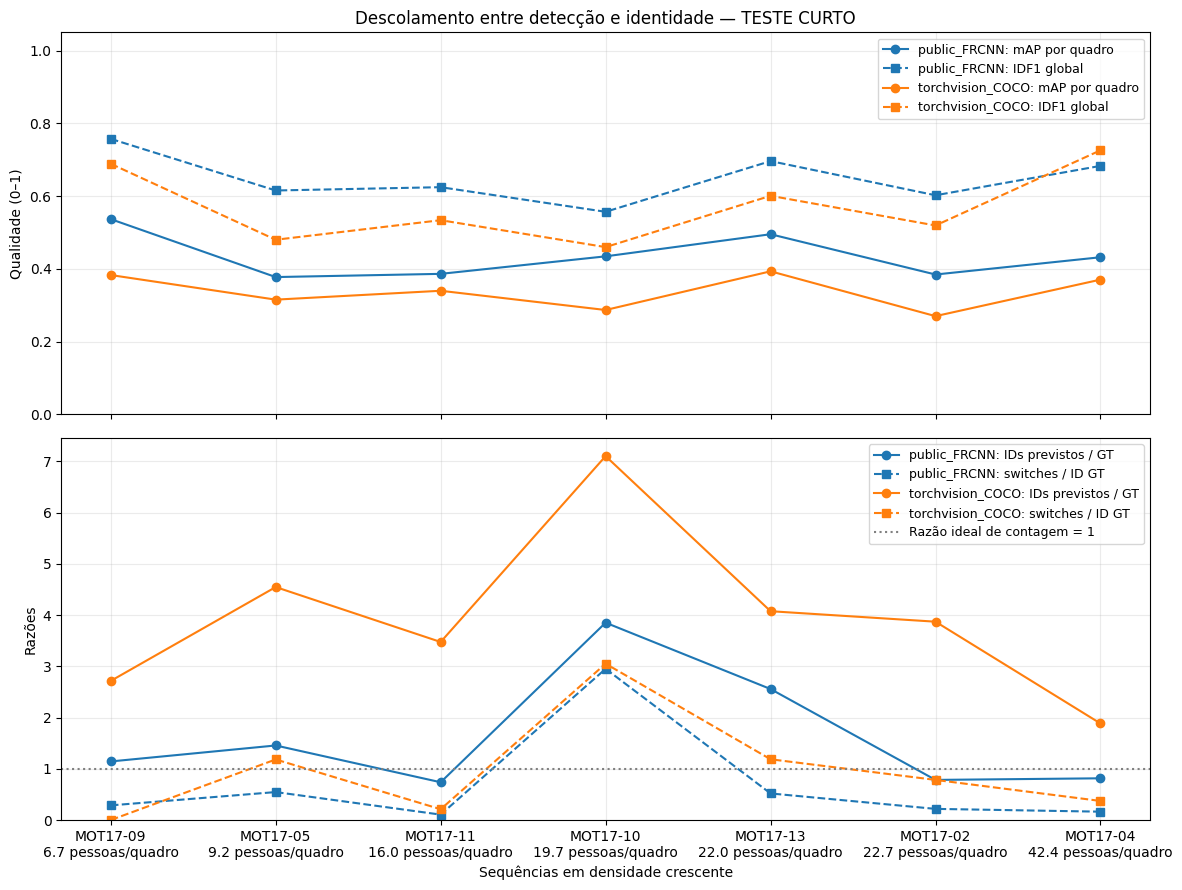

In [14]:
order = (results.groupby('sequence')['density'].first()
         .sort_values(kind='stable').index.tolist())
densities = results.groupby('sequence')['density'].first()
x = np.arange(len(order))
fig, (top, bottom) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
colors = {'public_FRCNN': 'tab:blue', 'torchvision_COCO': 'tab:orange'}
for source, color in colors.items():
    data = results[results.source == source].set_index('sequence').reindex(order)
    top.plot(x, data.mAP_frame_mean, 'o-', color=color, label=f'{source}: mAP por quadro')
    top.plot(x, data.IDF1, 's--', color=color, label=f'{source}: IDF1 global')
    bottom.plot(x, data.identity_ratio, 'o-', color=color, label=f'{source}: IDs previstos / GT')
    bottom.plot(x, data.switches_per_gt_id, 's--', color=color, label=f'{source}: switches / ID GT')
top.set_ylim(0, 1.05)
top.set_ylabel('Qualidade (0–1)')
top.set_title('Descolamento entre detecção e identidade' + (' — TESTE CURTO' if SMOKE_TEST else ''))
bottom.axhline(1, color='gray', linestyle=':', label='Razão ideal de contagem = 1')
bottom.set_ylim(bottom=0)
bottom.set_ylabel('Razões')
bottom.set_xticks(x, [f'{s}\n{densities[s]:.1f} pessoas/quadro' for s in order])
bottom.set_xlabel('Sequências em densidade crescente')
for ax in (top, bottom):
    ax.grid(alpha=.25)
    ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT / 'descolamento.png', dpi=180)
plt.show()


In [16]:
from matplotlib.patches import Rectangle
import colorsys

VIS_SEQUENCE_INDEX = 0
VIS_FRAME = None            # None: quadro mediano da sequência processada
VIS_EVENT_INDEX = 0         # primeiro evento cronológico; mude para inspecionar outros
TRAIL_LENGTH = 20
SOURCE_COLORS = {'public_FRCNN': 'tab:blue', 'torchvision_COCO': 'tab:orange'}
SOURCES = list(SOURCE_COLORS)

visual_seq = sequences[VIS_SEQUENCE_INDEX]
VIZ = OUTPUT / visual_seq.name / 'visualizations'
VIZ.mkdir(parents=True, exist_ok=True)

def csv_array(path, columns):
    return pd.read_csv(path)[columns].to_numpy(dtype=float).reshape(-1, len(columns))

def group_frames(array, frames, ncols):
    return {f: array[array[:, 0] == f, 1:].reshape(-1, ncols) for f in frames}

tables, visual_dets, visual_tracks, visual_events = {}, {}, {}, {}
for source in SOURCES:
    folder = OUTPUT / visual_seq.name / source
    tables[source] = pd.read_csv(folder / 'frame_metrics.csv').sort_values('frame')
    saved_frames = tables[source]['frame'].astype(int).tolist()
    visual_dets[source] = group_frames(csv_array(folder / 'detections.csv',
        ['frame','x1','y1','x2','y2','score']), saved_frames, 5)
    visual_tracks[source] = group_frames(csv_array(folder / 'tracks.csv',
        ['frame','id','x1','y1','x2','y2','score']), saved_frames, 6)
    visual_events[source] = pd.read_csv(folder / 'events.csv').sort_values('frame', kind='stable')

visual_frames = tables[SOURCES[0]]['frame'].astype(int).tolist()
if not visual_frames:
    raise ValueError('Nenhum quadro avaliado para visualizar.')
assert visual_frames == tables[SOURCES[1]]['frame'].astype(int).tolist(), 'As fontes devem usar os mesmos quadros.'
visual_gt, visual_ignore = load_gt(visual_seq, visual_frames)
evaluated_tracks = {source: {
    f: filter_ignored(visual_gt[f], visual_tracks[source][f], visual_ignore[f])
    for f in visual_frames} for source in SOURCES}
image_paths = {int(path.stem): path for path in (visual_seq / 'img1').iterdir()
               if path.suffix.lower() in {'.jpg','.jpeg','.png'}}
f_show = visual_frames[len(visual_frames)//2] if VIS_FRAME is None else int(VIS_FRAME)
if f_show not in visual_frames:
    raise ValueError('VIS_FRAME deve ser um quadro já processado.')
saved_config = json.loads((OUTPUT / 'config.json').read_text())
visual_suffix = ' — TESTE CURTO' if saved_config['smoke_test'] else ''

def load_image(frame):
    with Image.open(image_paths[frame]) as image:
        return np.asarray(image.convert('RGB'))

def id_color(identity):
    # Mesma identidade mantém cor dentro de uma fonte. IDs entre fontes são independentes.
    return colorsys.hsv_to_rgb((int(identity) * .61803398875) % 1, .8, .95)

def draw_boxes(ax, boxes, ids=None, color='lime', scores=None, linewidth=1.5):
    for j, (x1,y1,x2,y2) in enumerate(boxes):
        c = id_color(ids[j]) if ids is not None else color
        ax.add_patch(Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor=c, linewidth=linewidth))
        label = f'ID {int(ids[j])}' if ids is not None else ''
        if scores is not None:
            label += f' {scores[j]:.2f}'
        if label:
            ax.text(x1, y1, label.strip(), color='white', fontsize=7,
                    bbox=dict(facecolor=c, alpha=.8, edgecolor='none'), clip_on=True)

def finish_figure(fig, filename):
    fig.tight_layout()
    fig.savefig(VIZ / filename, dpi=160, bbox_inches='tight')
    plt.show()


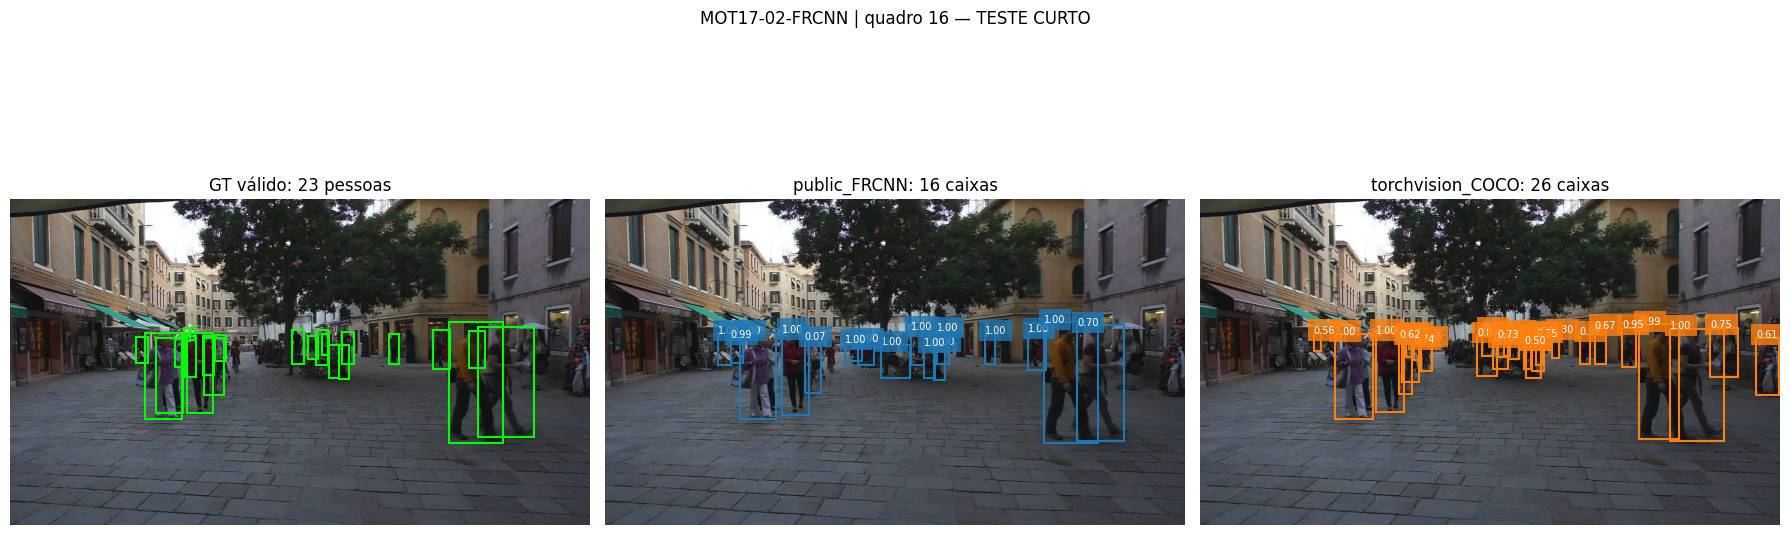

In [17]:
image = load_image(f_show)
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes[0].imshow(image)
draw_boxes(axes[0], visual_gt[f_show][:,1:5], color='lime')
axes[0].set_title(f'GT válido: {len(visual_gt[f_show])} pessoas')
for ax, source in zip(axes[1:], SOURCES):
    dets = visual_dets[source][f_show]
    ax.imshow(image)
    draw_boxes(ax, dets[:,:4], scores=dets[:,4], color=SOURCE_COLORS[source])
    ax.set_title(f'{source}: {len(dets)} caixas')
for ax in axes:
    ax.axis('off')
fig.suptitle(f'{visual_seq.name} | quadro {f_show}{visual_suffix}')
finish_figure(fig, '01_detection_comparison.png')


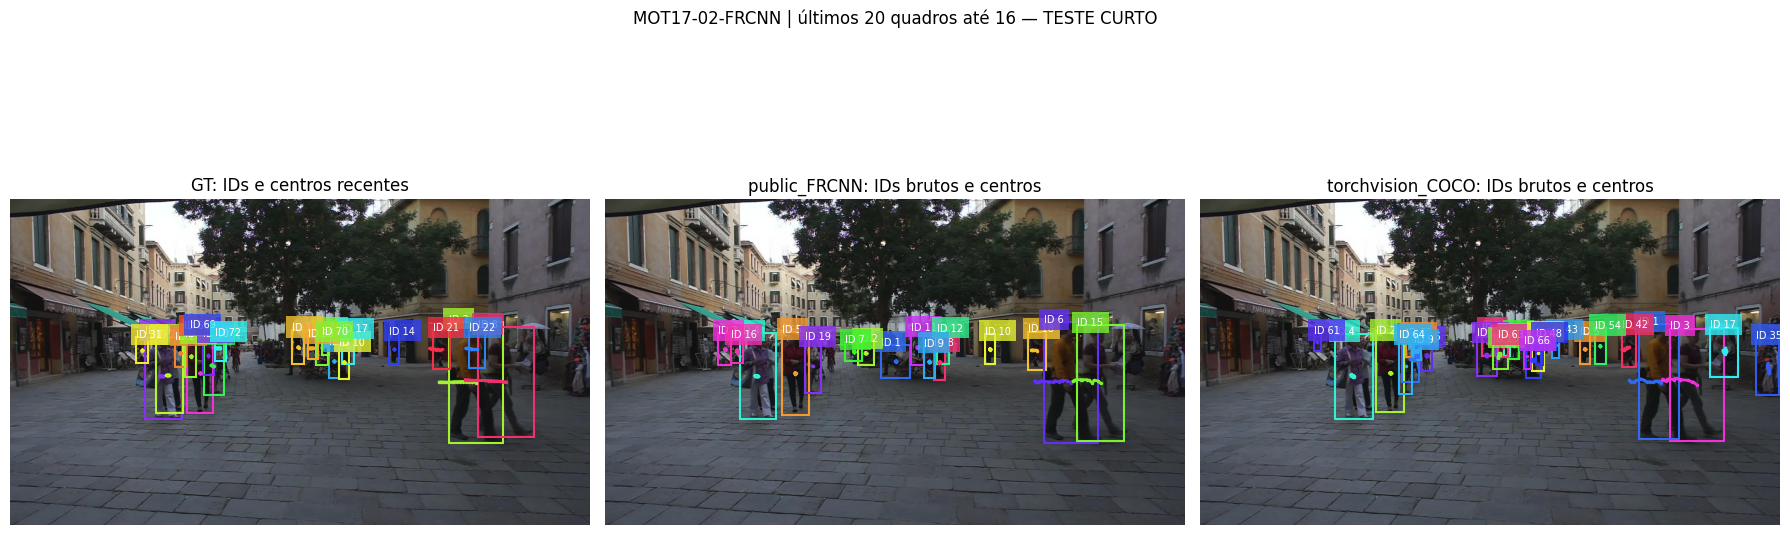

In [18]:
def draw_track_trails(ax, history, frame, score_column=False):
    current = history[frame]
    present = set(current[:,0].astype(int))
    points = {identity: [] for identity in present}
    for t in visual_frames:
        if frame - TRAIL_LENGTH < t <= frame:
            for row in history[t]:
                identity = int(row[0])
                if identity in points:
                    points[identity].append([t, (row[1]+row[3])/2, (row[2]+row[4])/2])
    for identity, values in points.items():
        values = np.array(values)
        breaks = np.where(np.diff(values[:,0]) > 1)[0] + 1
        for segment in np.split(values, breaks):
            ax.plot(segment[:,1], segment[:,2], '.-', color=id_color(identity), linewidth=2, markersize=3)
    draw_boxes(ax, current[:,1:5], ids=current[:,0])

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax in axes:
    ax.imshow(load_image(f_show))
    ax.axis('off')
draw_track_trails(axes[0], visual_gt, f_show)
axes[0].set_title('GT: IDs e centros recentes')
for ax, source in zip(axes[1:], SOURCES):
    draw_track_trails(ax, visual_tracks[source], f_show)
    ax.set_title(f'{source}: IDs brutos e centros')
fig.suptitle(f'{visual_seq.name} | últimos {TRAIL_LENGTH} quadros até {f_show}{visual_suffix}')
finish_figure(fig, '02_tracks_and_trails.png')


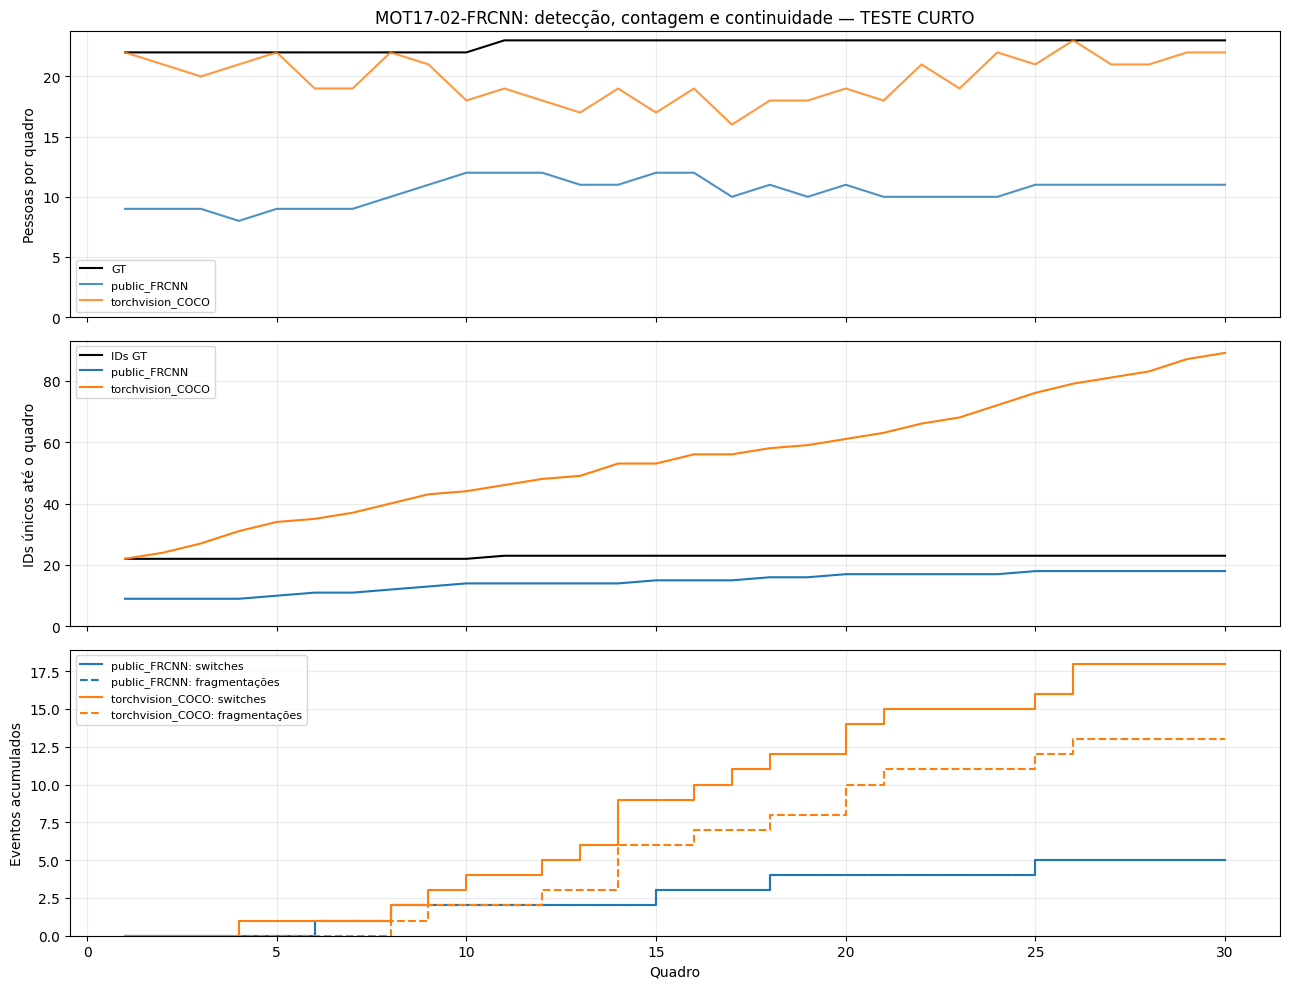

In [19]:
def cumulative_unique(history):
    seen, counts = set(), []
    for f in visual_frames:
        seen.update(history[f][:,0].astype(int))
        counts.append(len(seen))
    return counts

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
axes[0].plot(visual_frames, [len(visual_gt[f]) for f in visual_frames], color='black', label='GT')
axes[1].plot(visual_frames, cumulative_unique(visual_gt), color='black', label='IDs GT')
for source, color in SOURCE_COLORS.items():
    table = tables[source]
    axes[0].plot(table.frame, table.n_pred, color=color, alpha=.8, label=source)
    axes[1].plot(visual_frames, cumulative_unique(evaluated_tracks[source]), color=color, label=source)
    events = visual_events[source]
    for event_type, style, label in [('ID_switch','-','switches'),('fragmentation','--','fragmentações')]:
        counts = events.loc[events.event == event_type, 'frame'].value_counts()
        cumulative = np.cumsum([counts.get(f, 0) for f in visual_frames])
        axes[2].step(visual_frames, cumulative, where='post', color=color,
                     linestyle=style, label=f'{source}: {label}')
axes[0].set_ylabel('Pessoas por quadro')
axes[1].set_ylabel('IDs únicos até o quadro')
axes[2].set_ylabel('Eventos acumulados')
axes[2].set_xlabel('Quadro')
for ax in axes:
    ax.grid(alpha=.25)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
axes[0].set_title(f'{visual_seq.name}: detecção, contagem e continuidade{visual_suffix}')
finish_figure(fig, '03_counts_and_events_over_time.png')


Por quantos quadros cada identidade prevista foi observada?

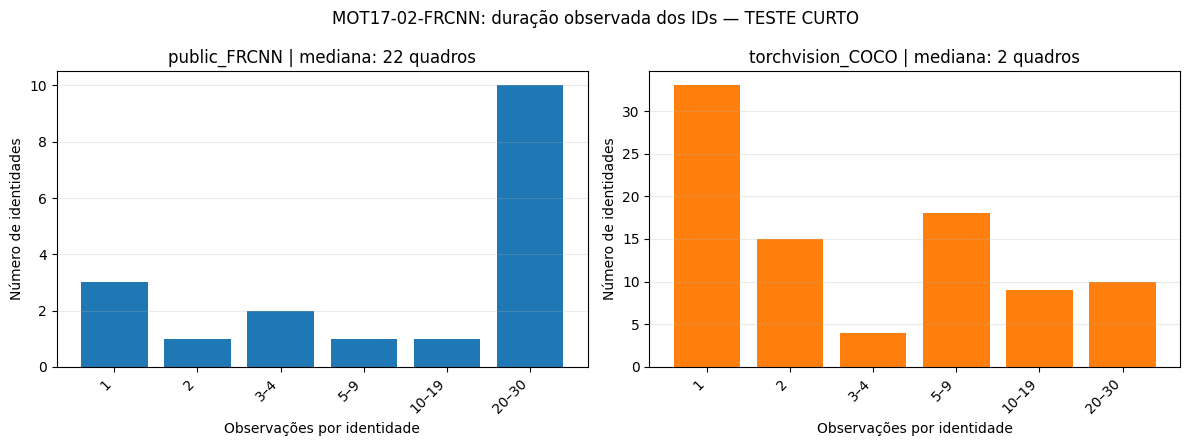

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (source, color) in zip(axes, SOURCE_COLORS.items()):
    observations = Counter(int(row[0]) for f in visual_frames for row in evaluated_tracks[source][f])
    durations = np.array(list(observations.values()), dtype=int)
    if len(durations):
        # Bordas inteiras com bins curtos no início; último cobre o vídeo.
        edges = np.unique([1,2,3,5,10,20,50,100,200,500,len(visual_frames)+1])
        edges = edges[edges <= max(len(visual_frames)+1, 2)]
        frequencies, _ = np.histogram(durations, bins=edges)
        labels = [str(a) if b == a+1 else f'{a}–{b-1}' for a,b in zip(edges[:-1],edges[1:])]
        ax.bar(np.arange(len(frequencies)), frequencies, color=color)
        ax.set_xticks(np.arange(len(labels)), labels, rotation=45, ha='right')
        ax.set_title(f'{source} | mediana: {np.median(durations):.0f} quadros')
    else:
        ax.text(.5,.5,'Sem IDs avaliados', transform=ax.transAxes, ha='center')
        ax.set_title(source)
    ax.set_xlabel('Observações por identidade')
    ax.set_ylabel('Número de identidades')
    ax.grid(axis='y', alpha=.25)
fig.suptitle(f'{visual_seq.name}: duração observada dos IDs{visual_suffix}')
finish_figure(fig, '04_identity_observation_lengths.png')


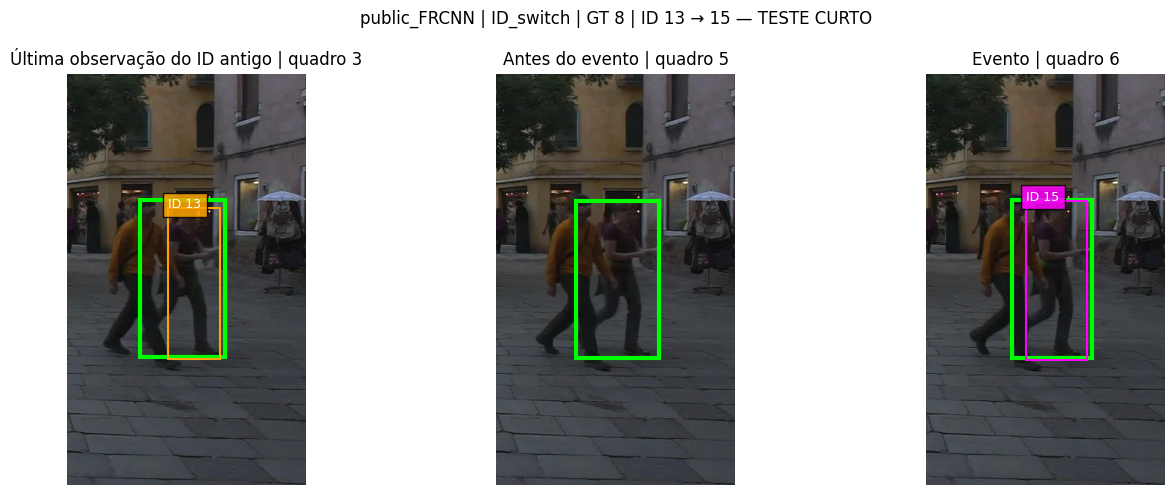

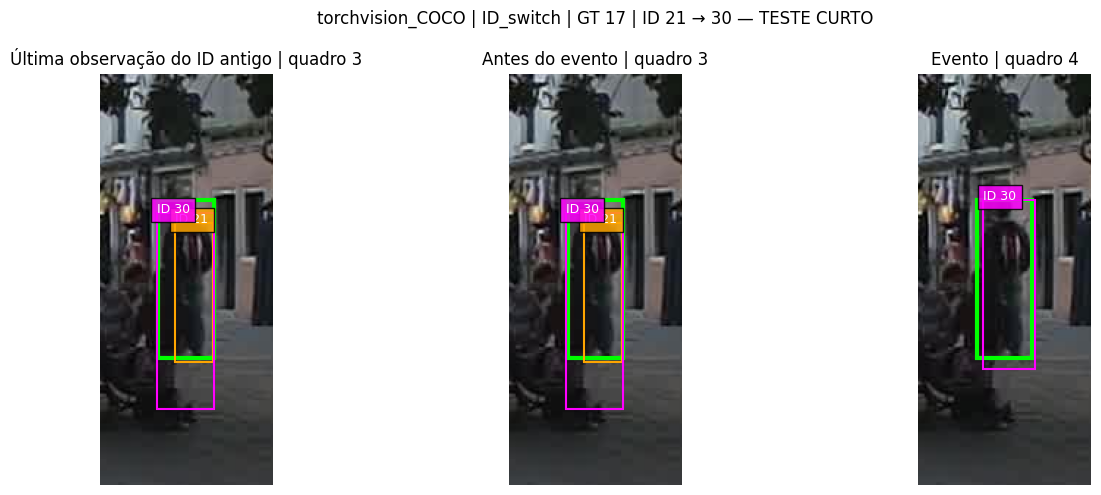

In [21]:
def draw_event_example(source, event_index=0):
    events = visual_events[source]
    if len(events) <= event_index or event_index < 0:
        print(f'{source}: não há evento no índice {event_index}.')
        return
    event = events.iloc[event_index]
    frame, target = int(event.frame), int(event.gt_id)
    old, new_id = int(event.old_pred_id), int(event.new_pred_id)
    previous = [f for f in visual_frames if f < frame]
    last_old = None
    for t in reversed(previous):
        g = visual_gt[t][visual_gt[t][:,0] == target]
        pred = evaluated_tracks[source][t]
        old_box = pred[pred[:,0] == old]
        if len(g) and len(old_box) and iou_matrix(g[:,1:5], old_box[:,1:5]).max() >= EVALUATION_IOU:
            last_old = t
            break
    chosen = [last_old if last_old is not None else previous[-1], previous[-1], frame] if previous else [frame]*3
    target_boxes = [row[1:5] for t in chosen for row in visual_gt[t] if int(row[0]) == target]
    img = load_image(frame)
    if target_boxes:
        boxes = np.array(target_boxes)
        low, high = boxes[:,:2].min(axis=0), boxes[:,2:].max(axis=0)
        margin = np.maximum((high-low) * .8, 40)
        x1,y1 = np.maximum(low-margin, 0)
        x2,y2 = np.minimum(high+margin, [img.shape[1], img.shape[0]])
    else:
        x1,y1,x2,y2 = 0,0,img.shape[1],img.shape[0]
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for ax, t, label in zip(axes, chosen, ['Última observação do ID antigo','Antes do evento','Evento']):
        ax.imshow(load_image(t))
        g = visual_gt[t][visual_gt[t][:,0] == target]
        draw_boxes(ax, g[:,1:5], color='lime', linewidth=3)
        for identity, color in dict([(old,'orange'), (new_id,'magenta')]).items():
            rows = evaluated_tracks[source][t]
            rows = rows[rows[:,0] == identity]
            draw_boxes(ax, rows[:,1:5], color=color)
            for row in rows:
                ax.text(row[1], row[2], f'ID {identity}', color='white', fontsize=9,
                        bbox=dict(facecolor=color, alpha=.85), clip_on=True)
        ax.set_xlim(x1,x2)
        ax.set_ylim(y2,y1)
        ax.set_title(f'{label} | quadro {t}')
        ax.axis('off')
    fig.suptitle(f'{source} | {event.event} | GT {target} | ID {old} → {new_id}{visual_suffix}')
    finish_figure(fig, f'05_event_{source}_{event_index:03}.png')

for source in SOURCES:
    draw_event_example(source, VIS_EVENT_INDEX)
